In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
#Importation des librairies
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import chi2_contingency, pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from pandas.plotting import scatter_matrix
from sklearn.cluster import KMeans

In [20]:

df_pays = pd.read_csv("df_pays.csv", sep=',')

df_scaled = pd.read_csv("df_scaled.csv", sep=',')



In [21]:
#ANALYSE CORRELATIONS

correlation_matrix = df_pays.corr(numeric_only=True)

print("Corrélation entre les variables")
print(correlation_matrix)

Corrélation entre les variables
                                                    Année  Population / 1000  \
Année                                                 NaN                NaN   
Population / 1000                                     NaN           1.000000   
dispo_Volailles_kg_personne_an                        NaN          -0.012248   
dispo_volaille_VS_Nourriture_totale_%                 NaN          -0.156398   
ratio_dispo_volaille_vs_autres_viandes                NaN          -0.092647   
ratio_prod_volaille_vs_autres_viandes                 NaN          -0.053047   
Disponibilités protéines moyennes d’origine ani...    NaN          -0.049835   
PIB par habitant, ($ PPA internationaux constan...    NaN          -0.010591   
Stabilité politique et absence de violence/terr...    NaN          -0.335840   

                                                    dispo_Volailles_kg_personne_an  \
Année                                                                          Na

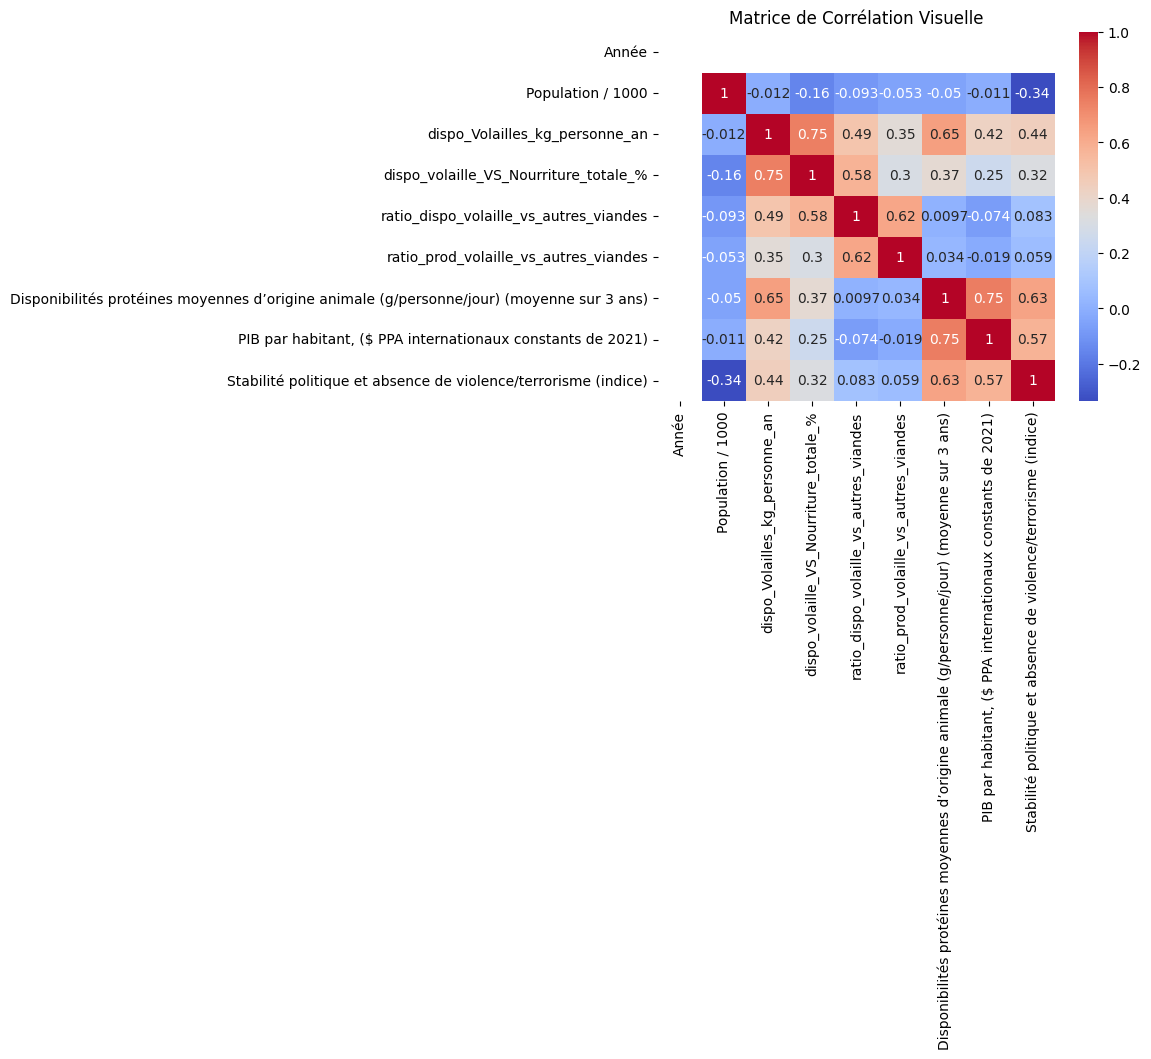

In [22]:
#Matrice de corrélation
correlation_matrix = df_pays.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    cbar=True
)

plt.title('Matrice de Corrélation Visuelle')
plt.show()

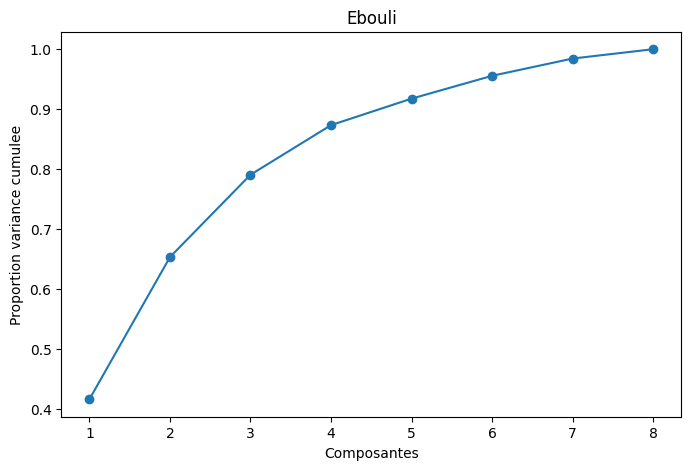

In [23]:
#EBOULI
df_pca = PCA()
df_pca.fit(df_scaled)

APC_variance = df_pca.explained_variance_ratio_


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(APC_variance) + 1), APC_variance.cumsum(), marker='o')
plt.xlabel("Composantes")
plt.ylabel("Proportion variance cumulee")
plt.title("Ebouli")
plt.show()


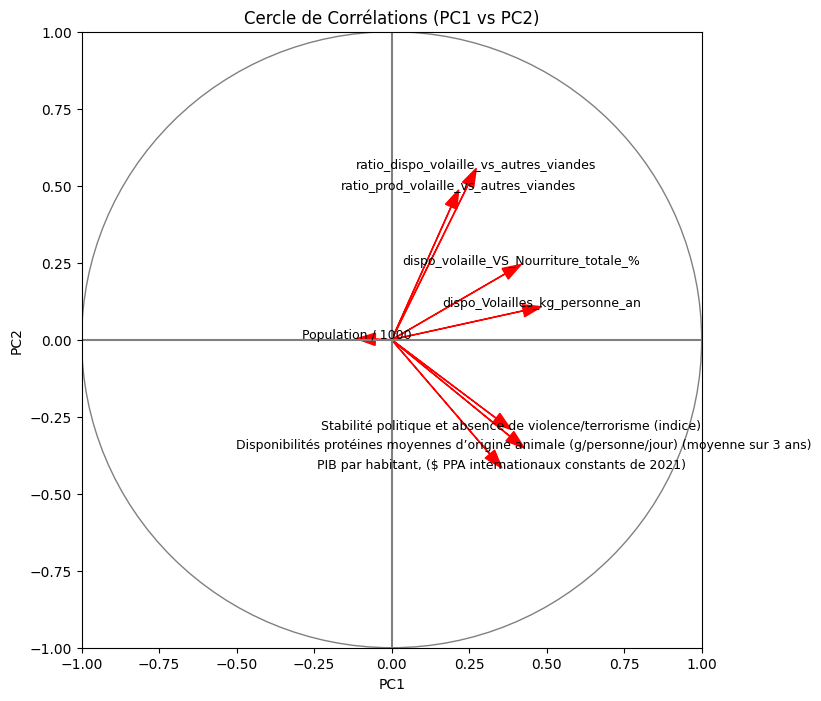

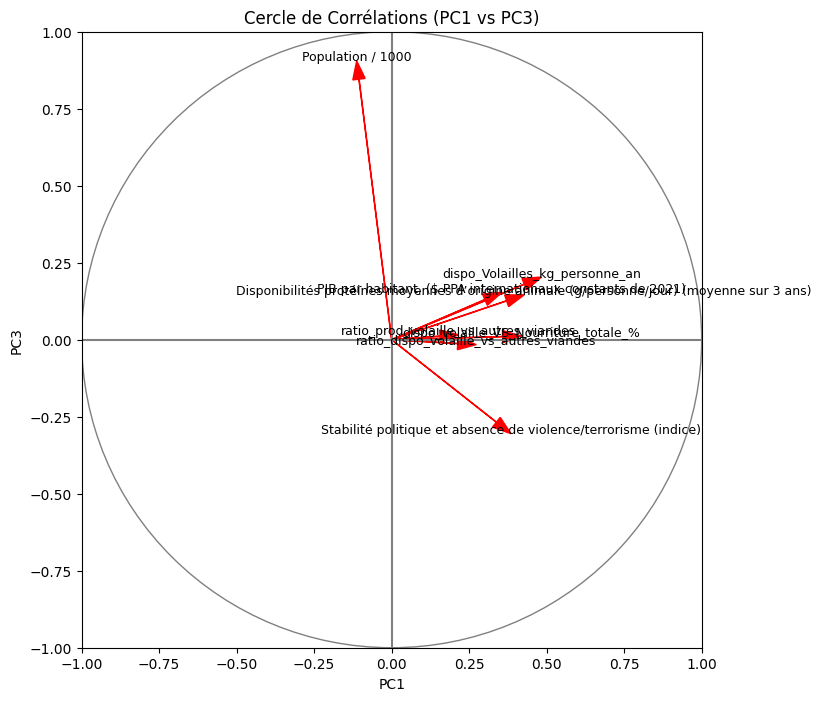

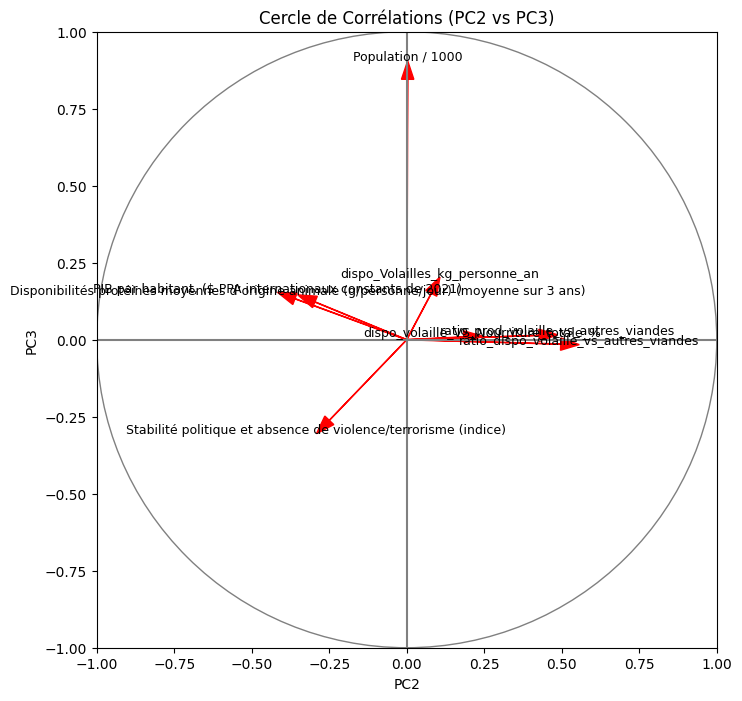

In [24]:
#Gardons 3 composantes pour atteindre + de 75% de variance

pca_final = PCA(n_components=3)
df_pca = pca_final.fit_transform(df_scaled)

nb_composantes = pca_final.n_components_
colonnes_pc = [f'PC{i+1}' for i in range(nb_composantes)]

coords_df = pd.DataFrame(pca_final.components_.T, columns=colonnes_pc, index=df_scaled.columns)


PC_cercles = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

#Graph cercles de corrélation pour les 3 options
for PC_x, PC_y in PC_cercles:
    plt.figure(figsize=(8, 8))
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)

    circle = plt.Circle((0,0), 1, fill=False, color='gray', linestyle='-')
    plt.gca().add_artist(circle)
    plt.axhline(0, linestyle='-', color='gray')
    plt.axvline(0, linestyle='-', color='gray')

    for variable, row in coords_df.iterrows():
        x = row[PC_x]
        y = row[PC_y]

        plt.arrow(0, 0, x, y, head_width= 0.04, color = 'red', length_includes_head=True)


        plt.text(x, y, variable, fontsize=9, ha='center')

    plt.title(f'Cercle de Corrélations ({PC_x} vs {PC_y})')
    plt.xlabel(PC_x)
    plt.ylabel(PC_y)
    plt.show()

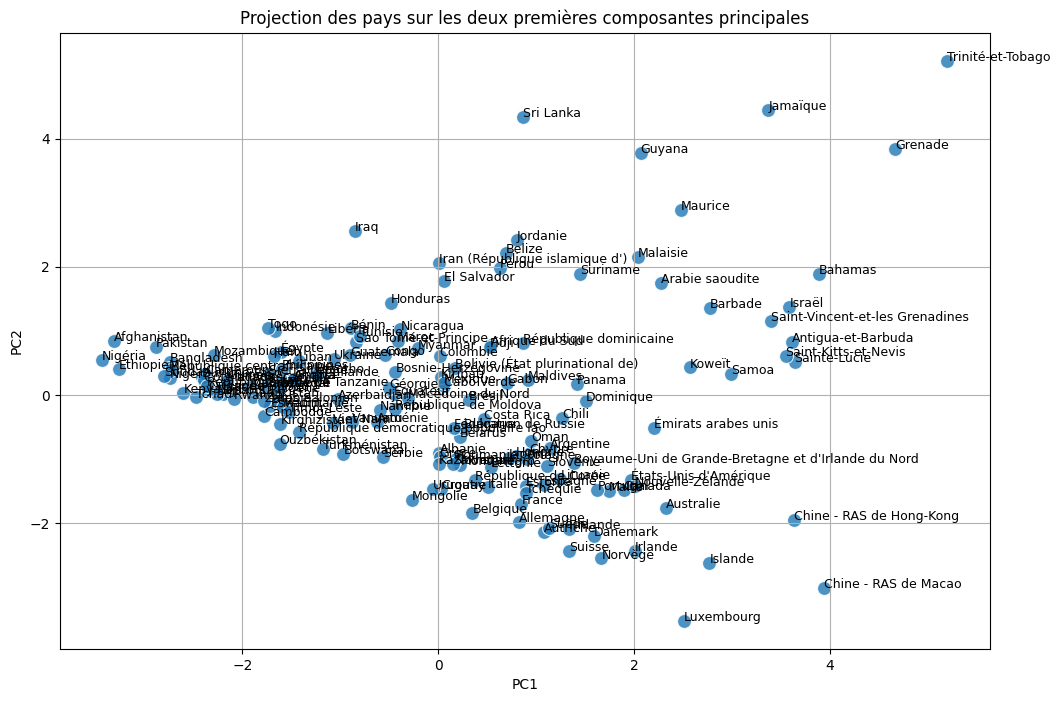

In [26]:


# Création d'un DataFrame avec les coordonnées des pays sur PC1 et PC2
df_pca_pour_visu = pd.DataFrame(
    data=df_pca[:, :2],
    columns=['PC1', 'PC2'],
    index=df_scaled.index
)

# Ajout du nom du pays
df_pca_pour_visu['Zone'] = df_pays.loc[df_pca_pour_visu.index, 'Zone']

# Visualisation simple
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=df_pca_pour_visu,
    s=100,
    alpha=0.8
)

# Ajout du nom des pays
for i, row in df_pca_pour_visu.iterrows():
    plt.text(row['PC1'], row['PC2'], row['Zone'], fontsize=9)

plt.title('Projection des pays sur les deux premières composantes principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()


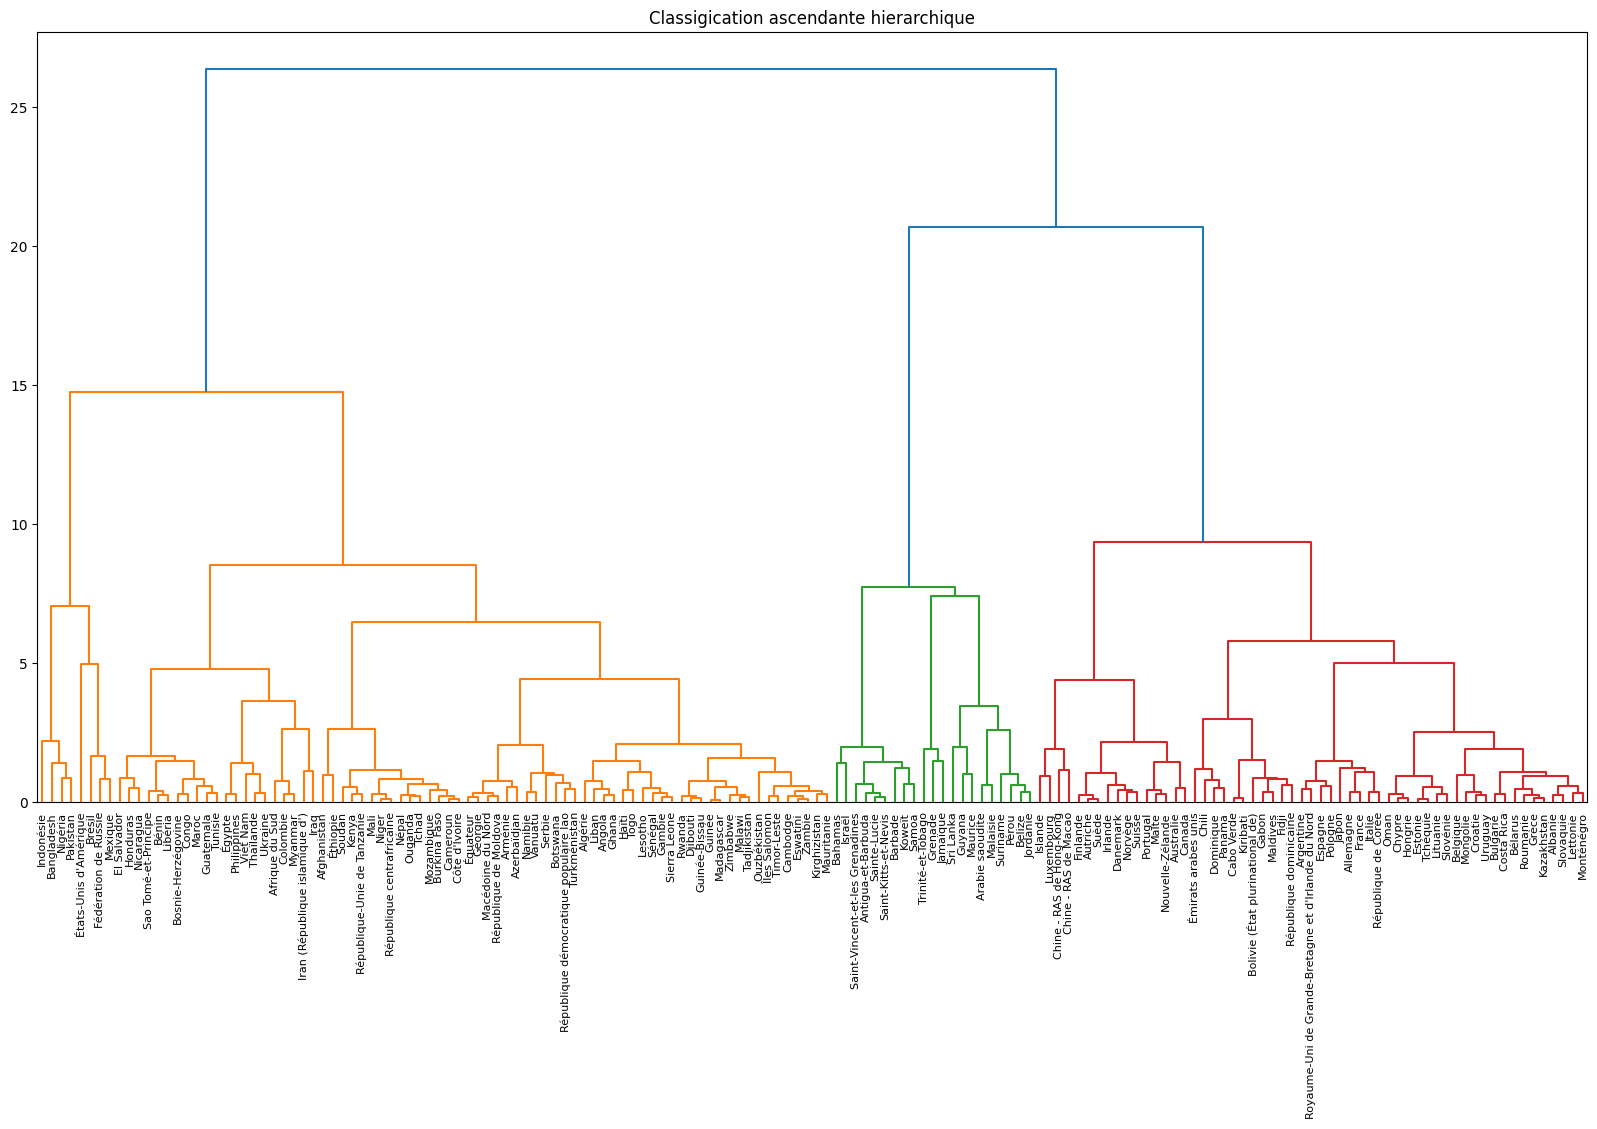

In [27]:
#Classigication ascendant hierarchique
distance_matrix = pdist(df_pca, metric='euclidean')


distance_matrix = linkage(distance_matrix, method='ward')
plt.figure(figsize=(20, 10))
plt.title('Classigication ascendante hierarchique')
dendrogram(distance_matrix, labels=df_pays['Zone'].values, leaf_rotation=90, leaf_font_size=8)
plt.show()

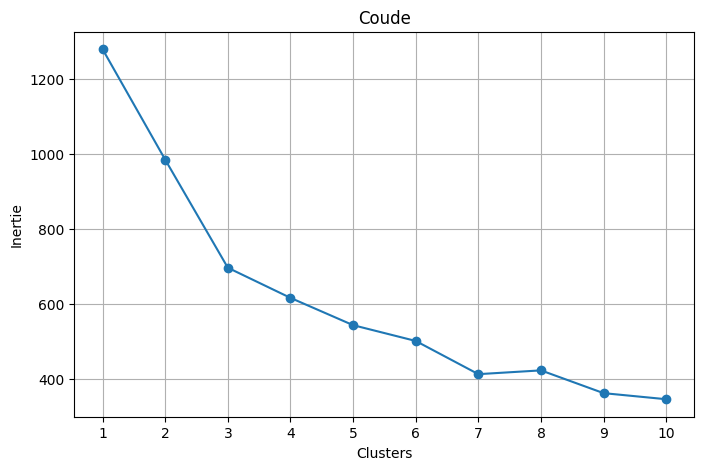

In [28]:

# Test de différents nombres de clusters
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Coude")
plt.xlabel("Clusters")
plt.ylabel("Inertie")
plt.xticks(K_range)
plt.grid(True)
plt.show()













In [29]:

K=3
cluster_finaux = KMeans(n_clusters=K, random_state=42)
clusters_finaux = cluster_finaux.fit_predict(df_scaled)


#ajout des clusters dans df
df_pays['Cluster'] = clusters_finaux
df_analyse = df_pays.copy()


colonnes_a_analyser = df_scaled.columns.tolist()
analyse_clusters = df_analyse.groupby('Cluster')[colonnes_a_analyser].mean()

#calcul des indicateurs moyennes et profils relatifs pour premiere analyse
moyenne_globale = df_analyse[colonnes_a_analyser].mean()
profil_relatif = (analyse_clusters / moyenne_globale * 100) - 100

print("Moyennes")
print(analyse_clusters.round(2))

print("Profil relatif")
print(profil_relatif.round(2))





Moyennes
         Population / 1000  dispo_Volailles_kg_personne_an  \
Cluster                                                      
0                 29322.84                           26.07   
1                  7026.52                           43.98   
2                 31326.95                            9.96   

         dispo_volaille_VS_Nourriture_totale_%  \
Cluster                                          
0                                         1.69   
1                                         4.64   
2                                         0.88   

         ratio_dispo_volaille_vs_autres_viandes  \
Cluster                                           
0                                          0.65   
1                                          3.54   
2                                          0.77   

         ratio_prod_volaille_vs_autres_viandes  \
Cluster                                          
0                                         0.60   
1                      

/tmp/ipython-input-3429047927.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3429047927.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3429047927.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3429047927.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3429047927.py:14: FutureWarning: 

Passin

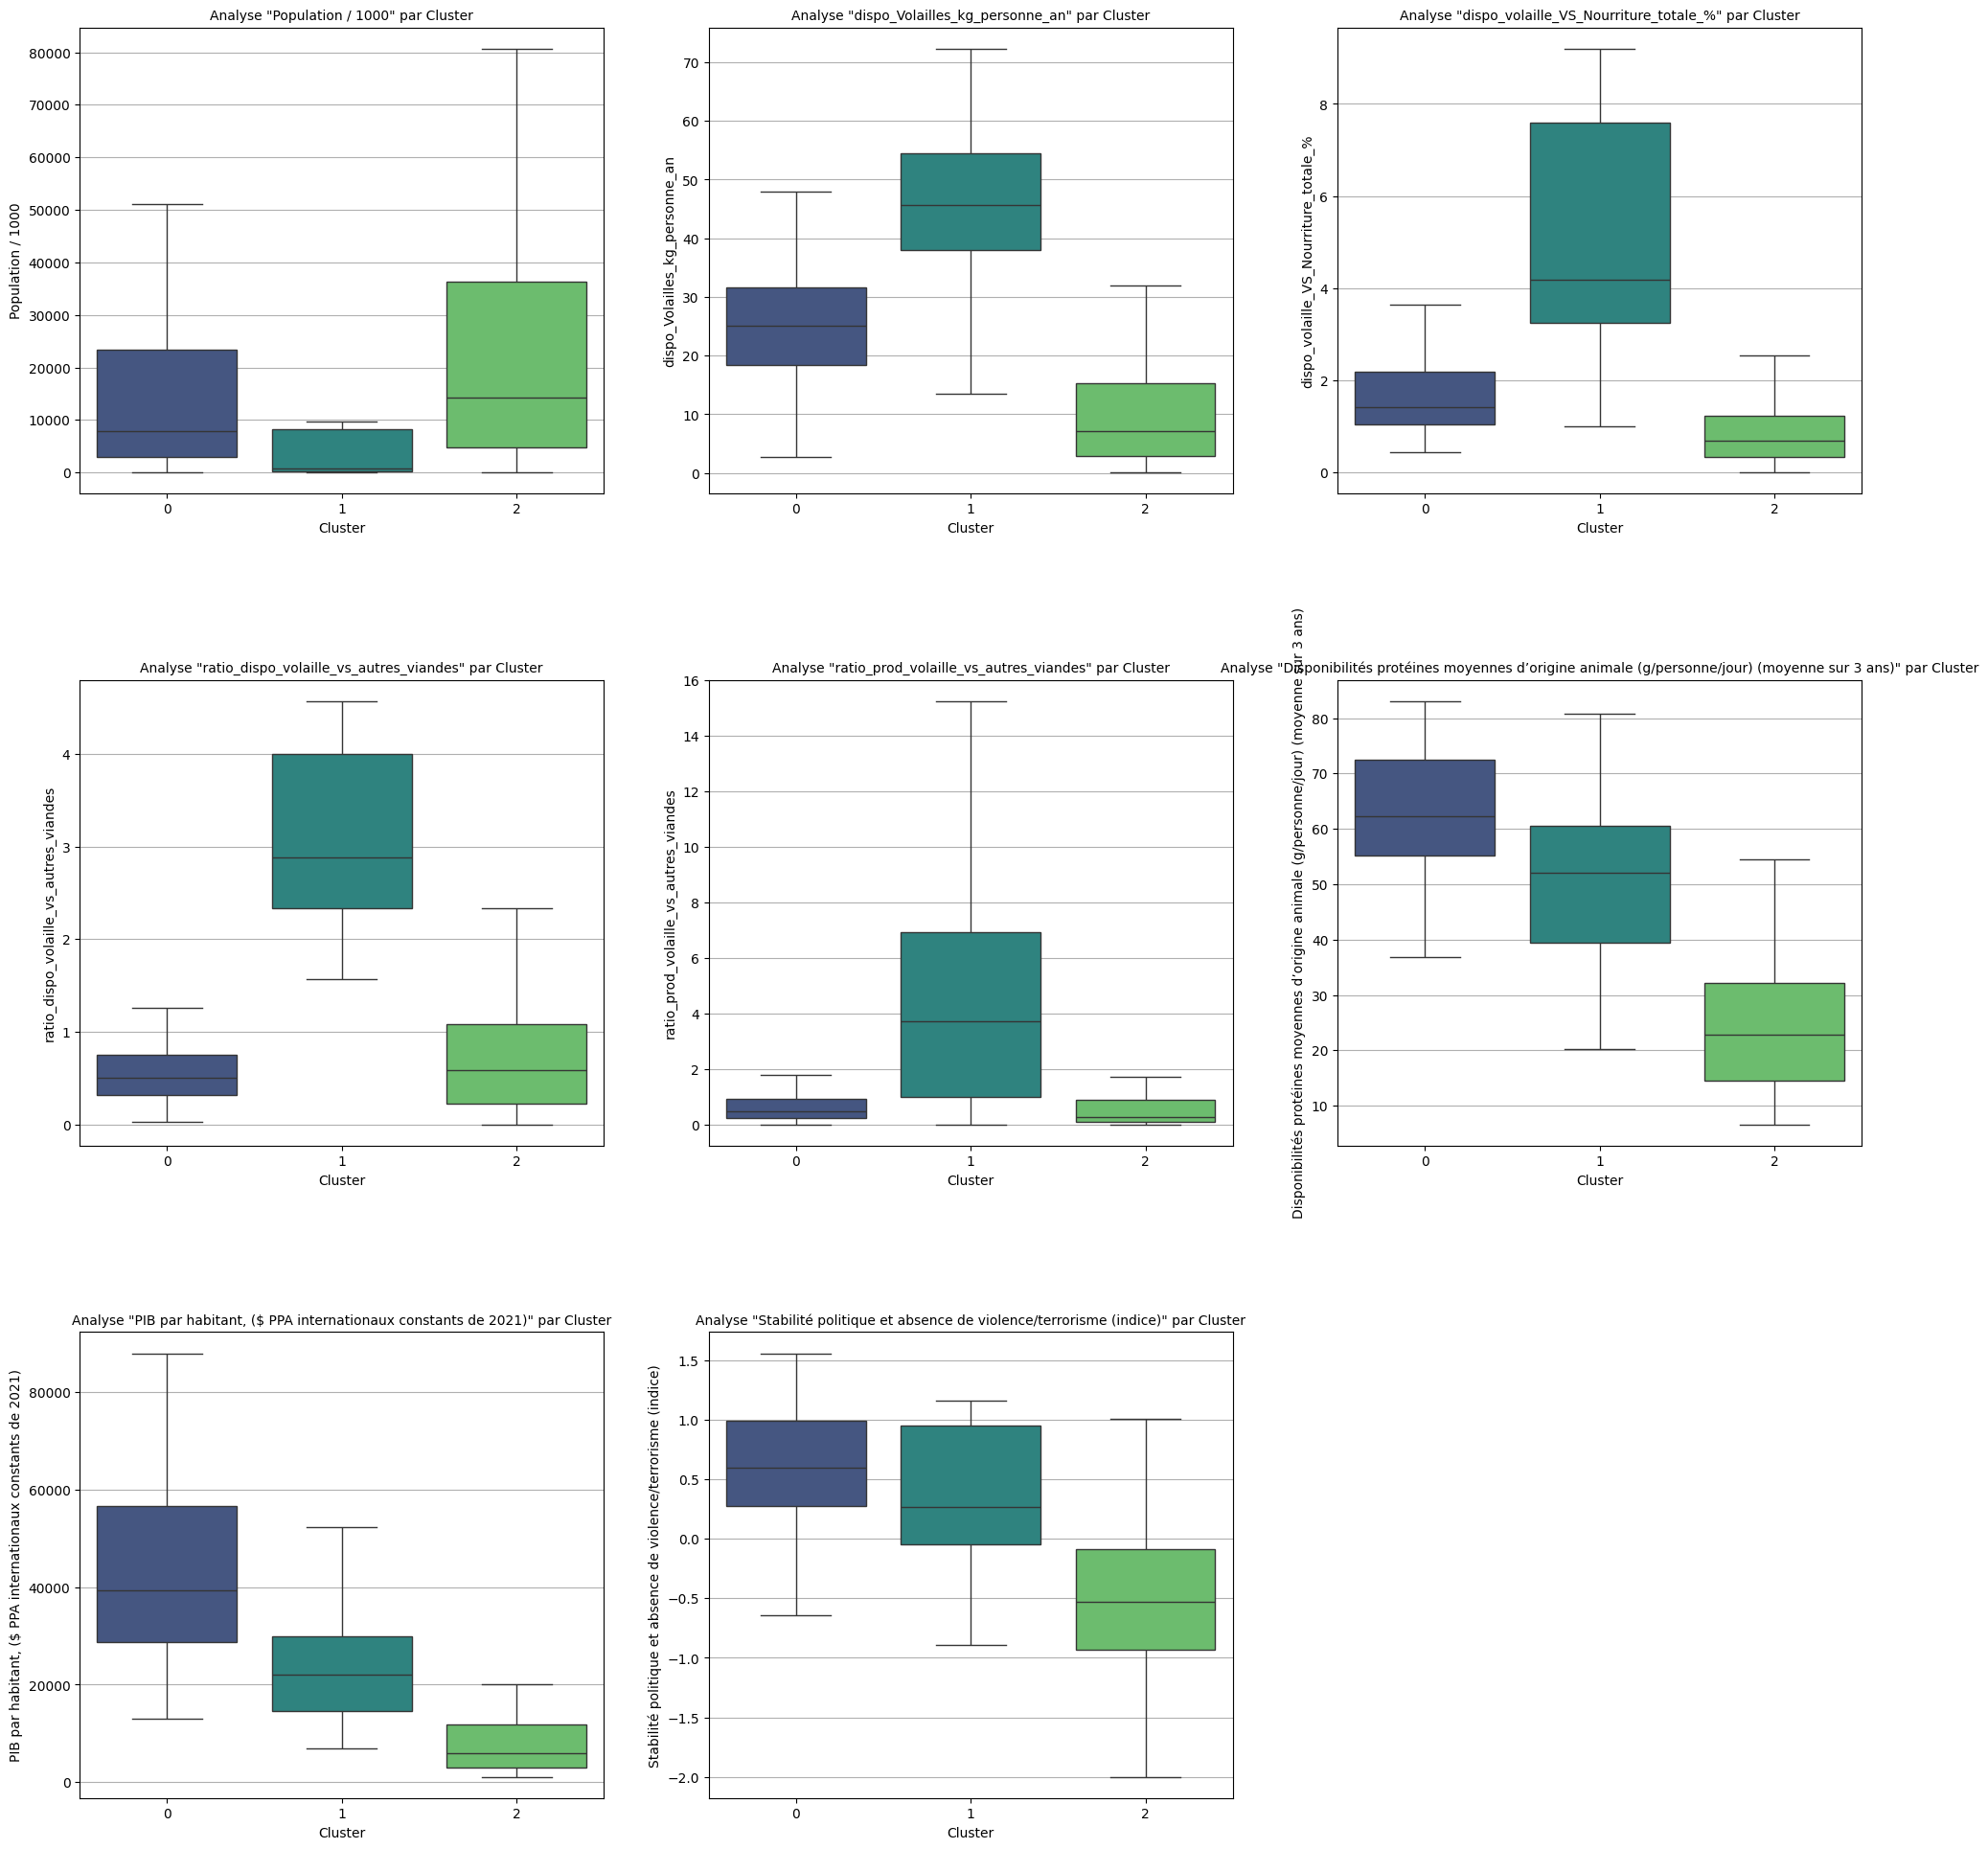

In [30]:
#On prend les variables non réduites
variables_a_plotter = df_scaled.columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(variables_a_plotter) / n_cols))

#Boxplot pour chaque varibale
plt.figure(figsize=(n_cols * 8, n_rows * 8))
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(variables_a_plotter):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(
        x='Cluster',
        y=col,
        data=df_analyse,
        palette='viridis',
        showfliers=False
    )

    plt.title(f'Analyse "{col}" par Cluster', fontsize=10)
    plt.xlabel(f'Cluster', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='-')
plt.show()

In [31]:
# Groupement par Cluster, puis concaténation des noms de pays (Zone)
liste_pays = df_analyse.groupby('Cluster')['Zone'].unique()

# Affichage du résultat
for cluster_id, pays in liste_pays.items():
    print("Cluster", {cluster_id}, ":          ", pays)


Cluster {0} :           ['Albanie' 'Allemagne' 'Argentine' 'Australie' 'Autriche' 'Bélarus'
 'Belgique' 'Brésil' 'Bulgarie' 'Canada' 'Chili'
 'Chine - RAS de Hong-Kong' 'Chine - RAS de Macao' 'Chypre' 'Costa Rica'
 'Croatie' 'Danemark' 'Dominique' 'Émirats arabes unis' 'Espagne'
 'Estonie' "États-Unis d'Amérique" 'Fédération de Russie' 'Fidji'
 'Finlande' 'France' 'Gabon' 'Grèce' 'Hongrie' 'Irlande' 'Islande'
 'Italie' 'Japon' 'Kazakhstan' 'Lettonie' 'Lituanie' 'Luxembourg'
 'Maldives' 'Malte' 'Mexique' 'Mongolie' 'Monténégro' 'Norvège'
 'Nouvelle-Zélande' 'Oman' 'Panama' 'Pologne' 'Portugal'
 'République de Corée' 'République dominicaine' 'Roumanie'
 "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord" 'Slovaquie'
 'Slovénie' 'Suède' 'Suisse' 'Tchéquie' 'Uruguay']
Cluster {1} :           ['Antigua-et-Barbuda' 'Arabie saoudite' 'Bahamas' 'Barbade' 'Belize'
 'Grenade' 'Guyana' 'Israël' 'Jamaïque' 'Jordanie' 'Koweït' 'Malaisie'
 'Maurice' 'Pérou' 'Sainte-Lucie' 'Saint-Kitts-et-Nevis'
 '